# Dataset Preparation & basic EDA
**Detect AI-Generated Faces**

Notebook này thực hiện:
1. Thu thập & validate ảnh từ 4 dataset (scan + dedup)
2. EDA — class balance, sample grid, pixel intensity histogram
3. Split 70 / 15 / 15 (stratified) → lưu `train.csv`, `val.csv`, `test.csv`

> **Lưu ý:** Preprocessing thực sự (resize 224×224, normalize ImageNet, augmentation) được thực hiện on-the-fly trong PyTorch `Dataset` lúc training.

In [1]:
import hashlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

ROOT = Path("../").resolve()
RAW = ROOT / "data" / "raw"
SPLITS_DIR = ROOT / "data" / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}
REAL_DIR_NAMES = {"real", "Real", "training_real"}
FAKE_DIR_NAMES = {"fake", "Fake", "training_fake"}

print(f"ROOT: {ROOT}")
print(f"RAW : {RAW}")

ROOT: D:\UIT\XyLyDuLieuLon_Thu5\DS200.F21.CN2.BigData
RAW : D:\UIT\XyLyDuLieuLon_Thu5\DS200.F21.CN2.BigData\data\raw


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Thu thập ảnh từ 4 dataset

In [2]:
SOURCES = [
    ("140k-StyleGAN",  RAW / "140k-real-and-fake-faces/real_vs_fake/real-vs-fake"),
    ("Deepfake-Real",  RAW / "deepfake-and-real-images/Dataset"),
    ("Hard-FakeReal",  RAW / "hardfakevsrealfaces"),
    ("ciplab",         RAW / "real-and-fake-face-detection/real_and_fake_face"),
]

def infer_label(path: Path) -> str | None:
    for part in reversed(path.parts):
        if part in REAL_DIR_NAMES:
            return "Real"
        if part in FAKE_DIR_NAMES:
            return "Fake"
    return None

records = []
per_dataset = {}

for name, source_dir in SOURCES:
    if not source_dir.exists():
        print(f"[WARN] Not found: {source_dir}")
        continue
    imgs = [p for p in source_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    ds_records = []
    for img_path in imgs:
        label = infer_label(img_path)
        if label is None:
            print(f"[WARN] Cannot infer label: {img_path}")
            continue
        ds_records.append({"image_path": str(img_path), "label": label, "dataset": name})
    records.extend(ds_records)
    per_dataset[name] = pd.DataFrame(ds_records)
    counts = pd.DataFrame(ds_records)["label"].value_counts()
    print(f"{name:20s}: {len(ds_records):>7,} images  |  Real={counts.get('Real',0):,}  Fake={counts.get('Fake',0):,}")

df_raw = pd.DataFrame(records)
print(f"\nTotal raw: {len(df_raw):,} images")

140k-StyleGAN       : 140,000 images  |  Real=70,000  Fake=70,000
Deepfake-Real       : 190,335 images  |  Real=95,201  Fake=95,134
Hard-FakeReal       :   1,289 images  |  Real=589  Fake=700
ciplab              :   2,041 images  |  Real=1,081  Fake=960

Total raw: 333,665 images


## 2. Hash-based Deduplication

In [3]:
def file_hash(path: str) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(65536):
            h.update(chunk)
    return h.hexdigest()

hashes = []
for p in tqdm(df_raw["image_path"], desc="Hashing"):
    hashes.append(file_hash(p))
df_raw["hash"] = hashes

before = len(df_raw)
df_dedup = df_raw.drop_duplicates(subset="hash").reset_index(drop=True)
removed = before - len(df_dedup)

print(f"Before dedup : {before:,}")
print(f"Removed      : {removed:,}")
print(f"After dedup  : {len(df_dedup):,}")

df = df_dedup.drop(columns=["hash"]).copy()

Hashing: 100%|██████████| 333665/333665 [21:18<00:00, 260.97it/s]


Before dedup : 333,665
Removed      : 17,135
After dedup  : 316,530


## 3. Kiểm tra Class Balance

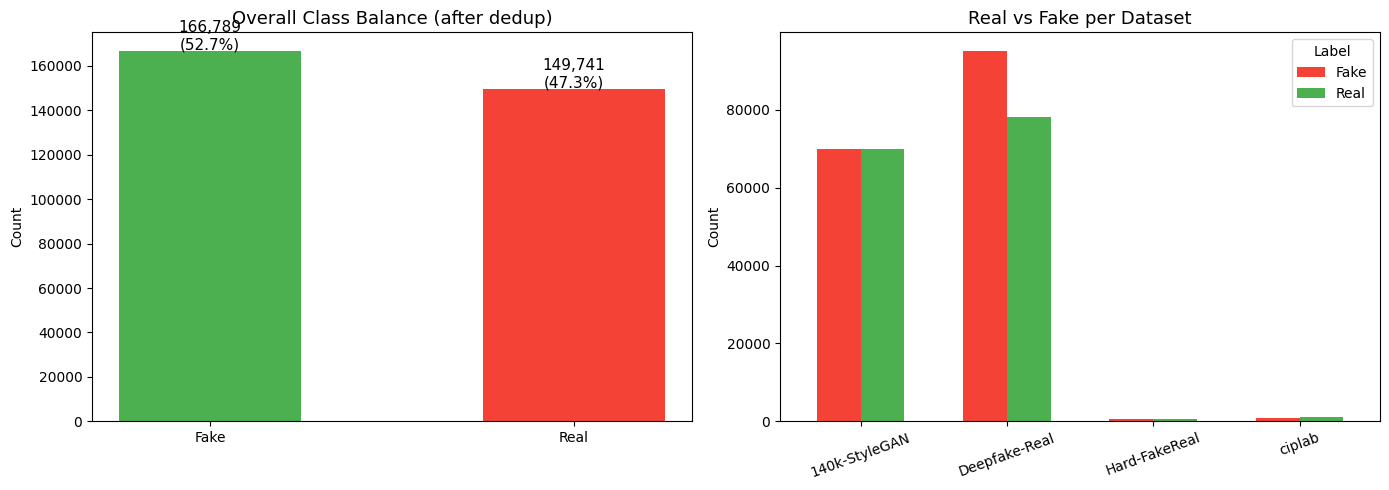

Imbalance ratio: 0.898 [OK]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall balance
counts = df["label"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], width=0.5)
axes[0].set_title("Overall Class Balance (after dedup)", fontsize=13)
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 500, f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)

# Per-dataset breakdown
breakdown = df.groupby(["dataset", "label"]).size().unstack(fill_value=0)
breakdown.plot(kind="bar", ax=axes[1], color=["#F44336", "#4CAF50"], width=0.6)
axes[1].set_title("Real vs Fake per Dataset", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Label")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = counts.min() / counts.max()
print(f"Imbalance ratio: {ratio:.3f}", "[OK]" if ratio >= 0.6 else "[WARN] Imbalanced — dùng class_weight")

## 4. Sample Grid — Real vs Fake từng Dataset

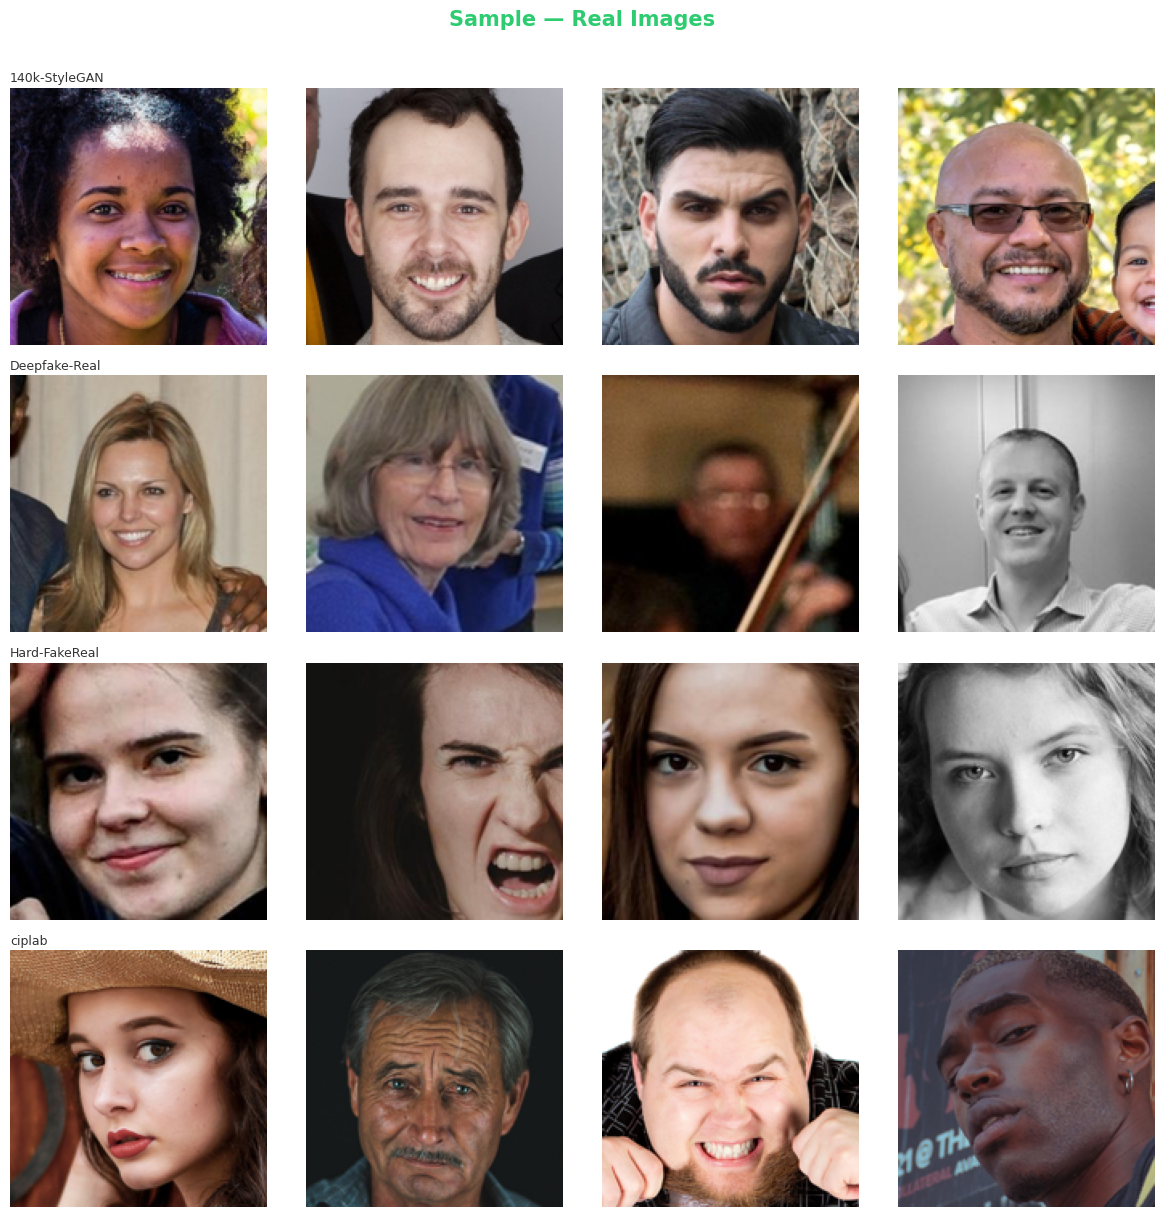

Saved: reports/sample_grid_real.png


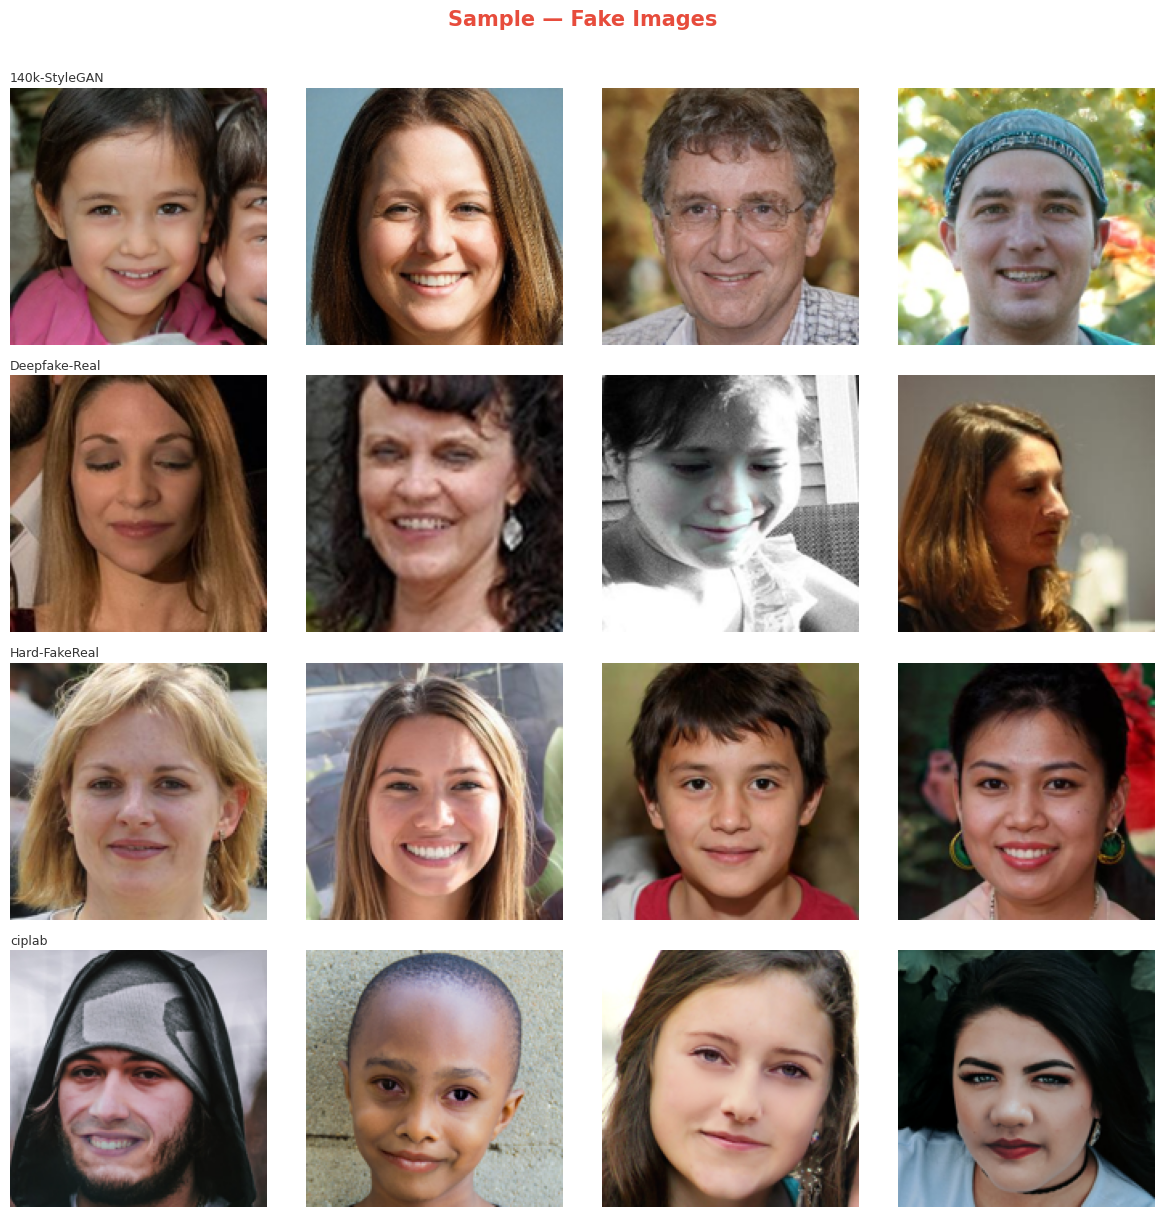

Saved: reports/sample_grid_fake.png


In [5]:
datasets = list(df["dataset"].unique())
n_per = 4  # số ảnh mỗi dataset

for label, color in [("Real", "#2ecc71"), ("Fake", "#e74c3c")]:
    fig, axes = plt.subplots(len(datasets), n_per, figsize=(n_per * 3, len(datasets) * 3))
    fig.suptitle(f"Sample — {label} Images", fontsize=15, fontweight="bold", color=color, y=1.01)

    for row, ds_name in enumerate(datasets):
        subset = df[(df["dataset"] == ds_name) & (df["label"] == label)]
        samples = subset.sample(min(n_per, len(subset)), random_state=42)["image_path"].tolist()
        for col in range(n_per):
            ax = axes[row][col]
            if col < len(samples):
                img = Image.open(samples[col]).convert("RGB").resize((160, 160))
                ax.imshow(img)
            else:
                ax.set_facecolor("#f0f0f0")
            ax.axis("off")
            if col == 0:
                ax.set_title(ds_name, fontsize=9, loc="left", pad=4, color="#333333")

    plt.tight_layout()
    fname = f"sample_grid_{label.lower()}.png"
    plt.savefig(ROOT / "reports" / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: reports/{fname}")

## 5. Pixel Intensity Histogram — Real vs Fake

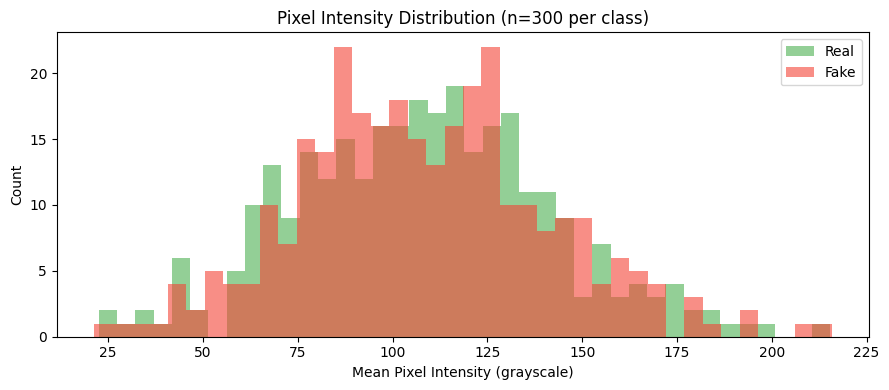

In [6]:
N_SAMPLE = 300  # số ảnh sample để vẽ histogram (tránh chậm)

def mean_pixel_intensity(paths):
    values = []
    for p in tqdm(paths, desc="Loading pixels", leave=False):
        arr = np.array(Image.open(p).convert("L").resize((64, 64)), dtype=np.float32)
        values.append(arr.mean())
    return values

real_paths = df[df["label"] == "Real"]["image_path"].sample(N_SAMPLE, random_state=42).tolist()
fake_paths = df[df["label"] == "Fake"]["image_path"].sample(N_SAMPLE, random_state=42).tolist()

real_intensity = mean_pixel_intensity(real_paths)
fake_intensity = mean_pixel_intensity(fake_paths)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(real_intensity, bins=40, alpha=0.6, color="#4CAF50", label="Real")
ax.hist(fake_intensity, bins=40, alpha=0.6, color="#F44336", label="Fake")
ax.set_xlabel("Mean Pixel Intensity (grayscale)")
ax.set_ylabel("Count")
ax.set_title(f"Pixel Intensity Distribution (n={N_SAMPLE} per class)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Split 70 / 15 / 15 (stratified)

In [7]:
train_df, temp_df = train_test_split(
    df[["image_path", "label"]], test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"{'Split':<8} {'Total':>8}  {'Real':>8}  {'Fake':>8}")
print("-" * 38)
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    c = split["label"].value_counts()
    print(f"{name:<8} {len(split):>8,}  {c.get('Real',0):>8,}  {c.get('Fake',0):>8,}")

Split       Total      Real      Fake
--------------------------------------
Train     221,571   104,819   116,752
Val        47,479    22,461    25,018
Test       47,480    22,461    25,019


## 7. Lưu CSV

In [8]:
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

print(f"Saved to {SPLITS_DIR}")
print(f"  train.csv : {len(train_df):,} rows")
print(f"  val.csv   : {len(val_df):,} rows")
print(f"  test.csv  : {len(test_df):,} rows")

Saved to D:\UIT\XyLyDuLieuLon_Thu5\DS200.F21.CN2.BigData\data\splits
  train.csv : 221,571 rows
  val.csv   : 47,479 rows
  test.csv  : 47,480 rows
